In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
d:\project bluestock\notebooks


In [4]:
import pandas as pd

# Load datasets
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")
performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [7]:
# Convert date columns

nav_history["date"] = pd.to_datetime(nav_history["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# Convert numeric columns

nav_history["nav"] = pd.to_numeric(nav_history["nav"])

performance["aum_crore"] = pd.to_numeric(performance["aum_crore"])
performance["return_1yr_pct"] = pd.to_numeric(performance["return_1yr_pct"])
performance["return_3yr_pct"] = pd.to_numeric(performance["return_3yr_pct"])
performance["return_5yr_pct"] = pd.to_numeric(performance["return_5yr_pct"])
performance["expense_ratio_pct"] = pd.to_numeric(performance["expense_ratio_pct"])

transactions["amount_inr"] = pd.to_numeric(transactions["amount_inr"])

print("Data types converted successfully!")

Data types converted successfully!


In [8]:
print("NAV History")
nav_history.info()

print("\nPerformance")
performance.info()

print("\nTransactions")
transactions.info()

NAV History
<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB

Performance
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     

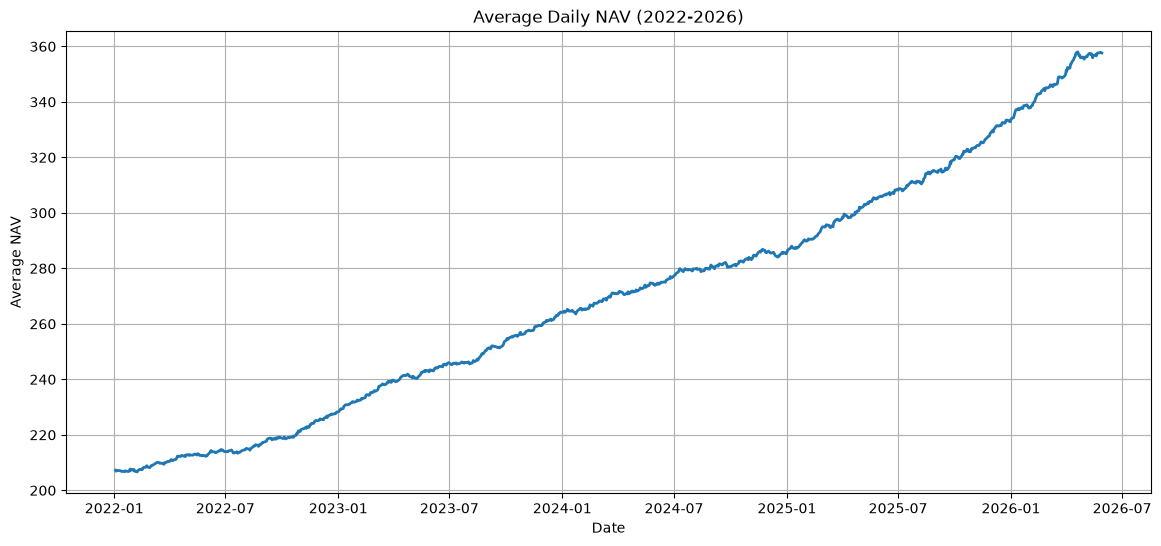

In [9]:
# Average NAV by date

daily_nav = (
    nav_history
    .groupby("date")["nav"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_nav["date"],
    daily_nav["nav"],
    linewidth=2
)

plt.title("Average Daily NAV (2022-2026)")
plt.xlabel("Date")
plt.ylabel("Average NAV")
plt.grid(True)

plt.show()

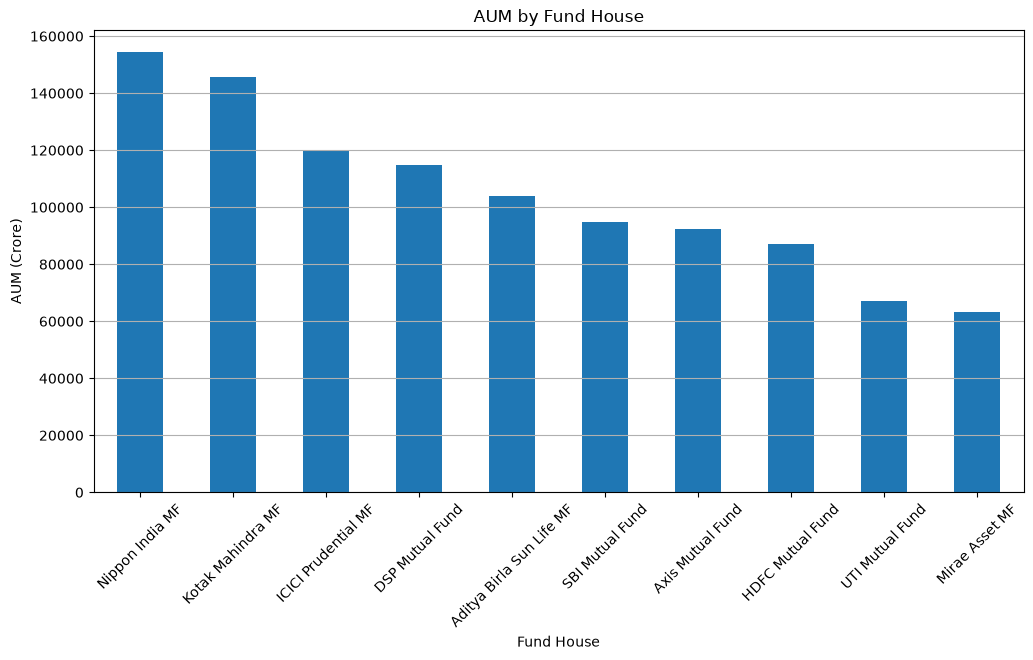

In [10]:
# Average AUM by Fund House

aum_by_house = (
    performance
    .groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

aum_by_house.plot(kind="bar")

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

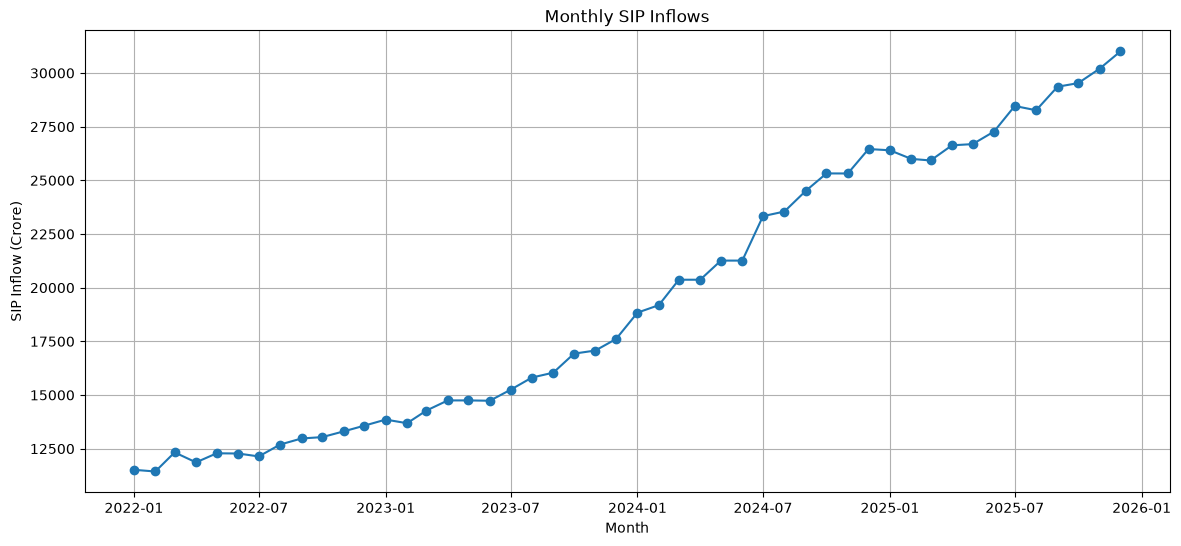

In [11]:
# Monthly SIP Inflow Trend

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

In [12]:
# Load Category Inflow Dataset

category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.head())

print(category.columns)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


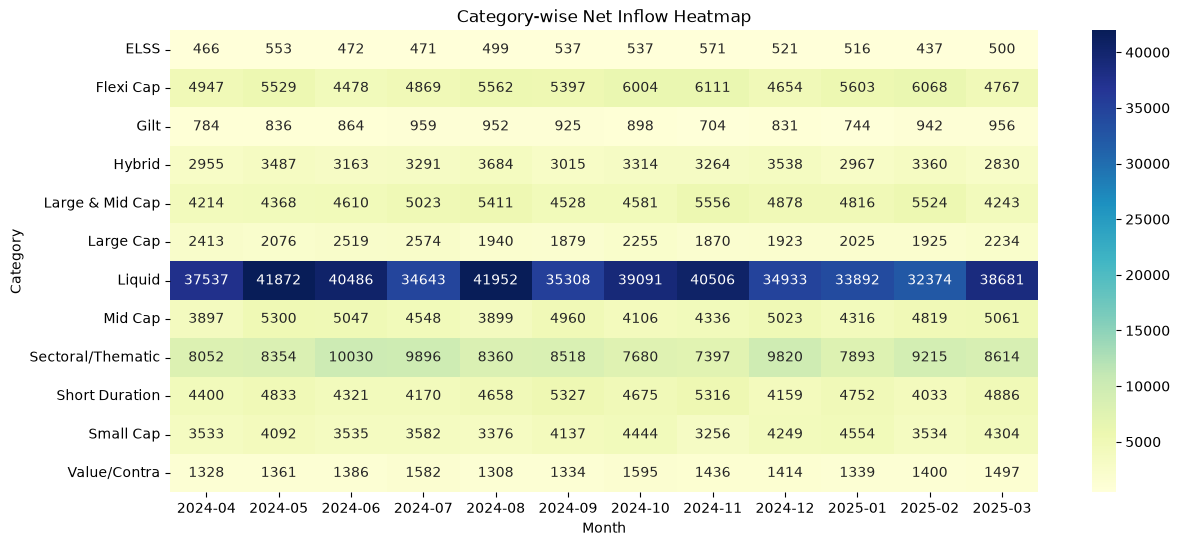

In [13]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Convert back to Month-Year format
category["month"] = category["month"].dt.strftime("%Y-%m")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [14]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


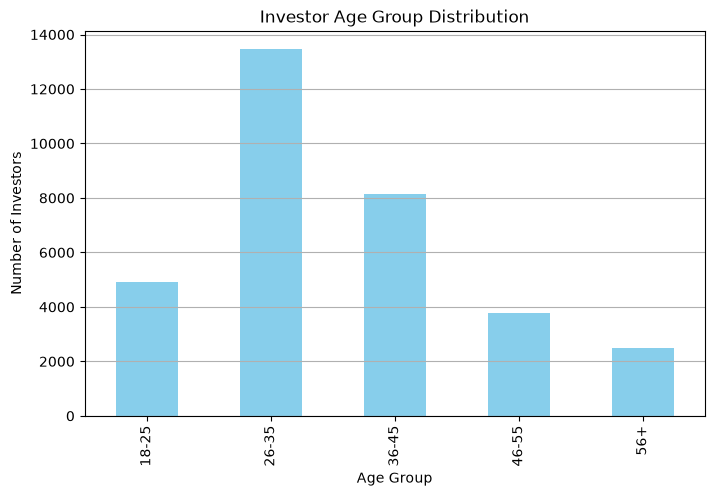

In [15]:
# Age Group Distribution

plt.figure(figsize=(8,5))

transactions["age_group"].value_counts().sort_index().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")
plt.grid(axis="y")

plt.show()

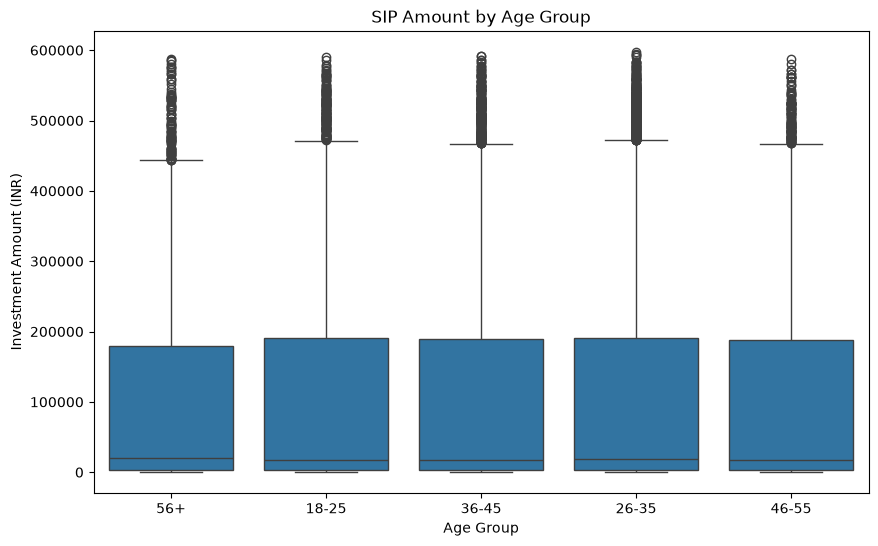

In [16]:
# SIP Amount by Age Group

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

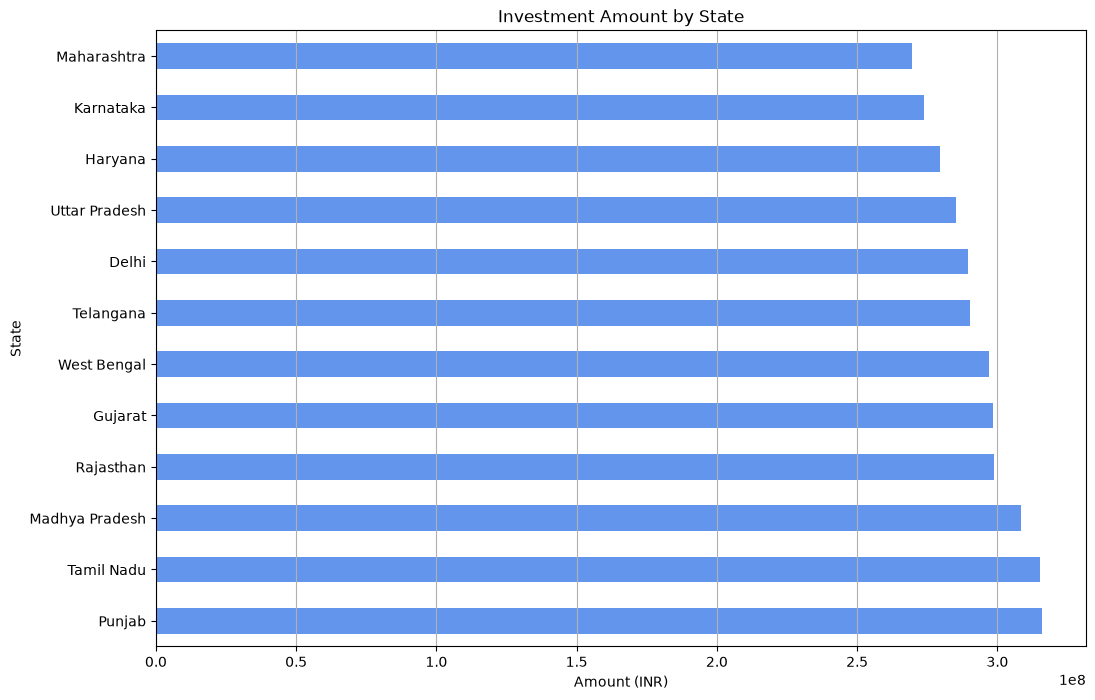

In [17]:
# State-wise Investment Amount

state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_amount.plot(
    kind="barh",
    color="cornflowerblue"
)

plt.title("Investment Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.grid(axis="x")

plt.show()

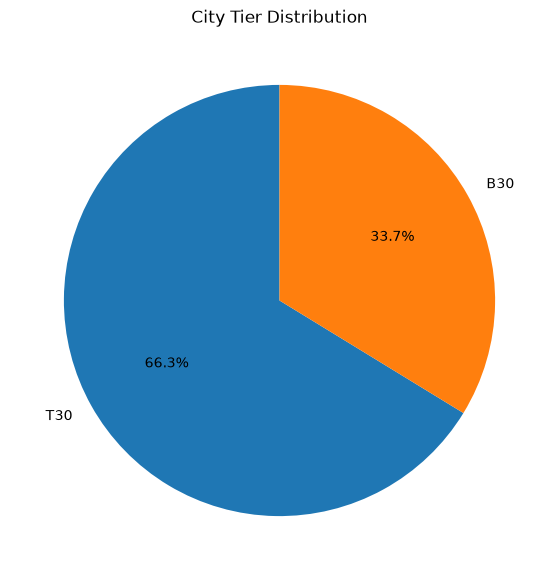

In [19]:
# City Tier Distribution

city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("City Tier Distribution")

plt.show()

In [5]:
print("===== FUND MASTER =====")
display(fund_master.head())

print("===== NAV HISTORY =====")
display(nav_history.head())

print("===== PERFORMANCE =====")
display(performance.head())

print("===== TRANSACTIONS =====")
display(transactions.head())

===== FUND MASTER =====


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


===== NAV HISTORY =====


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


===== PERFORMANCE =====


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


===== TRANSACTIONS =====


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
print("===== FUND MASTER =====")
display(fund_master.head())

print("===== NAV HISTORY =====")
display(nav_history.head())

print("===== PERFORMANCE =====")
display(performance.head())

print("===== TRANSACTIONS =====")
display(transactions.head())

===== FUND MASTER =====


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


===== NAV HISTORY =====


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


===== PERFORMANCE =====


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


===== TRANSACTIONS =====


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [21]:
# Sort data

nav_history = nav_history.sort_values(["amfi_code", "date"])

# Calculate Daily Returns

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [22]:
# Create Pivot Table

returns = nav_history.pivot_table(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,...,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


In [23]:
correlation_matrix = returns.corr()

correlation_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
amfi_code,,,,,,,,,,,,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781,...,0.023033,-0.006097,0.047139,-0.016089,0.002264,0.004676,0.045290,0.035192,-0.010164,0.028672
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166,...,-0.003257,0.022290,0.011326,-0.025505,0.010897,-0.017995,-0.010431,-0.002087,-0.000398,0.020955
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318,...,0.023025,0.010619,-0.025137,-0.011916,-0.000268,0.038488,-0.006109,-0.049355,0.018986,-0.060504
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432,...,-0.008136,0.009300,-0.020000,-0.009070,-0.021644,-0.004259,0.023468,0.021622,-0.000607,-0.004785
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384,...,0.058576,-0.075322,-0.046542,0.022493,0.015678,-0.050823,-0.002198,0.020669,0.011435,-0.006471
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507,...,-0.005261,0.068618,-0.045579,-0.026233,-0.046154,0.018977,-0.072459,0.020234,0.027775,-0.010105
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285,...,-0.011661,0.009177,-0.016497,0.045540,0.033777,-0.042668,0.023487,0.039516,-0.014542,0.002378
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886,...,-0.060225,-0.032191,-0.045802,-0.015054,-0.007621,0.009632,-0.008490,0.011213,-0.014376,-0.081325
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248,...,0.026651,-0.060195,0.068349,0.058162,0.001225,-0.037190,-0.022496,-0.035493,0.008908,0.043256


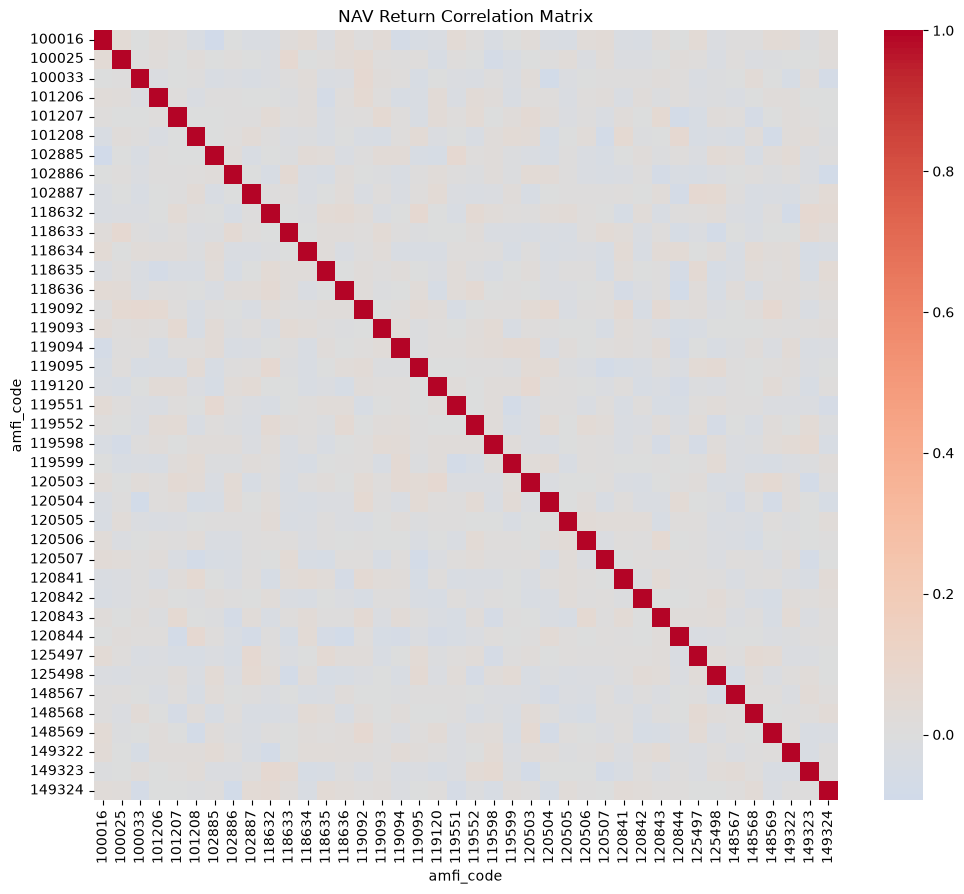

In [24]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix")

plt.show()

In [25]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio.head())

print(portfolio.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [26]:
# Total portfolio allocation by sector

sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

print(sector_data)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


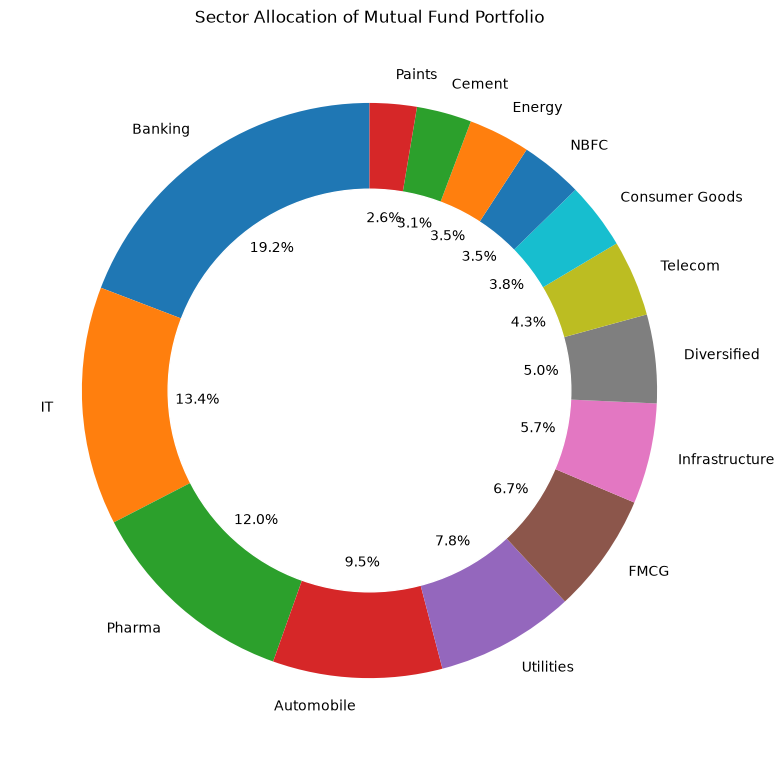

In [27]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90
)

# Create donut hole
centre_circle = plt.Circle((0,0),0.70,color="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation of Mutual Fund Portfolio")

plt.tight_layout()

plt.show()

# Key EDA Findings

### 1. NAV Trend
The average NAV of mutual funds has shown a steady upward trend from 2022 to 2026, indicating overall market growth.

### 2. AUM Growth
SBI Mutual Fund has the highest Assets Under Management (AUM), making it the market leader among fund houses.

### 3. SIP Inflows
Monthly SIP inflows increased consistently and reached their highest level towards the end of the analysis period.

### 4. Category-wise Inflows
Mid Cap and Flexi Cap funds attracted higher investor inflows compared to other categories.

### 5. Investor Age Distribution
The 26–35 age group represents the largest share of mutual fund investors.

### 6. Investment Amount by Age
Investment amounts vary across age groups, with several high-value investments observed in every category.

### 7. Geographic Distribution
Maharashtra recorded the highest total investment amount among all states.

### 8. City Tier Distribution
T30 cities contribute approximately two-thirds of the total investments, indicating stronger participation from major urban areas.

### 9. NAV Correlation
Most mutual funds exhibit a strong positive correlation in daily returns, reflecting similar market movements.

### 10. Sector Allocation
Banking and other major sectors account for the largest share of portfolio allocation, showing diversified investments across industries.

In [32]:
print("Fund Master Columns")
print(fund_master.columns)

print("\nNAV History Columns")
print(nav_history.columns)

print("\nPerformance Columns")
print(performance.columns)

print("\nTransactions Columns")
print(transactions.columns)

Fund Master Columns
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

NAV History Columns
Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

Performance Columns
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

Transactions Columns
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
    